# Actividad 2 — Aprendizaje por Refuerzo: Diferencia Temporal
## SARSA y Q-Learning en Blackjack-v1

**Asignatura:** Aprendizaje Automático
**Corte:** 3er Corte
**Entorno:** `Blackjack-v1` (gym)
**Algoritmos:** SARSA (on-policy) y Q-Learning (off-policy)

**Integrantes:**
- Nicolás Hurtado
- Sofía Gonzalez
- Mateo Llanos

---
## Punto 1 — Exploración del Entorno

Antes de entrenar cualquier agente, caracterizamos formalmente el entorno para entender el espacio de estados, las acciones disponibles, la función de recompensa y las condiciones de terminación.

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict
import gym

# Bloque A — Espacio de observación y acciones
env = gym.make('Blackjack-v1', natural=False, sab=False)
print("Espacio de observacion:", env.observation_space)
print("Espacio de acciones   :", env.action_space)
np.random.seed(42)
obs = env.reset()
print(f"Observacion de ejemplo: {obs}")
print(f"  player_sum={obs[0]}, dealer_card={obs[1]}, usable_ace={obs[2]}")
env.close()

Espacio de observacion: Tuple(Discrete(32), Discrete(11), Discrete(2))
Espacio de acciones   : Discrete(2)
Observacion de ejemplo: (11, 7, False)
  player_sum=11, dealer_card=7, usable_ace=False


### 1.1 Descripción formal del entorno

`gym.make('Blackjack-v1', natural=False, sab=False)`

| Componente | Rango alcanzable | Significado |
|---|---|---|
| `player_sum` | 4 – 21 | Suma de cartas del jugador (mínimo 2+2, máximo sin pasarse) |
| `dealer_card` | 1 – 10 | Carta visible del dealer (As = 1, figuras = 10) |
| `usable_ace` | False / True | `True` = el jugador tiene un As contado como 11 sin pasarse |
| **Acción 0** | — | **Stand**: el jugador se planta; el dealer juega hasta ≥ 17 |
| **Acción 1** | — | **Hit**: el jugador pide una carta adicional |

> La tabla Q se implementa como `defaultdict` indexado por la tupla de estado, ya que el espacio de estados no es una cuadrícula con índices enteros directos.

**Función de recompensa (`natural=False`):**

| Resultado | Recompensa |
|---|---|
| Jugador gana (incluyendo blackjack natural) | +1 |
| Empate | 0 |
| Jugador pierde o se pasa de 21 (bust) | −1 |

> Con `natural=False` el blackjack natural (As + figura en primer reparto) da +1, igual que cualquier victoria. Con `natural=True` daría +1.5 — eso era el comportamiento de Blackjack-v0 usado en la actividad de Monte Carlo.

**Condición de terminación:**
- El jugador se pasa de 21 → episodio termina con reward = −1
- El jugador elige Stand → el dealer juega hasta ≥ 17 → se comparan las manos

In [73]:
# Bloque B — Episodio con política aleatoria
env = gym.make('Blackjack-v1', natural=False, sab=False)
np.random.seed(42)
obs = env.reset()

print(f"{'Paso':<6} {'Estado (sum, dealer, ace)':<30} {'Accion':<10} {'Reward':<10} {'Done'}")
print("-" * 72)
print(f"{'0':<6} {str(obs):<30} {'—':<10} {'—':<10} —")

step = 0
done = False
while not done:
    action = env.action_space.sample()
    next_obs, reward, done, _ = env.step(action)
    accion_str = 'Hit' if action == 1 else 'Stand'
    print(f"{step+1:<6} {str(next_obs):<30} {accion_str:<10} {reward:<10} {done}")
    obs = next_obs
    step += 1
env.close()

Paso   Estado (sum, dealer, ace)      Accion     Reward     Done
------------------------------------------------------------------------
0      (7, 10, False)                 —          —          —
1      (11, 10, False)                Hit        0.0        False
2      (21, 10, False)                Hit        0.0        False
3      (26, 10, False)                Hit        -1.0       True


**Interpretación del episodio anterior:**
Cada fila muestra el estado DESPUÉS de tomar la acción indicada. La semilla 42 garantiza reproducibilidad.
El episodio termina cuando el jugador se planta (Stand) o se pasa de 21 (bust). La recompensa final (+1 / 0 / −1) solo se observa al terminar.

In [74]:
# Bloque C — Línea base: 1000 episodios con política aleatoria
N_BASELINE = 1000

env = gym.make('Blackjack-v1', natural=False, sab=False)
np.random.seed(42)
wins, draws, losses, rewards_ep = 0, 0, 0, []

for _ in range(N_BASELINE):
    obs = env.reset()
    done = False; ep_reward = 0
    while not done:
        action = env.action_space.sample()
        obs, reward, done, _ = env.step(action)
        ep_reward += reward
    rewards_ep.append(ep_reward)
    if ep_reward > 0:    wins   += 1
    elif ep_reward == 0: draws  += 1
    else:                losses += 1
env.close()

rewards_arr     = np.array(rewards_ep)
baseline_mean   = rewards_arr.mean()
baseline_win_rate = wins / N_BASELINE

print("=" * 52)
print("  LÍNEA BASE — Política Aleatoria (1000 eps)")
print("=" * 52)
print(f"  Recompensa promedio : {rewards_arr.mean():.4f}")
print(f"  Desv. estándar      : {rewards_arr.std():.4f}")
print(f"  Tasa de victoria    : {wins/N_BASELINE:.3f}  ({wins}/1000)")
print(f"  Tasa de empate      : {draws/N_BASELINE:.3f}  ({draws}/1000)")
print(f"  Tasa de derrota     : {losses/N_BASELINE:.3f}  ({losses}/1000)")
print(f"\n  'Éxito' = victoria (reward > 0). Empates NO cuentan.")
print(f"  Umbral a superar con TD: recompensa promedio = {rewards_arr.mean():.4f}")

  LÍNEA BASE — Política Aleatoria (1000 eps)
  Recompensa promedio : -0.3660
  Desv. estándar      : 0.9089
  Tasa de victoria    : 0.297  (297/1000)
  Tasa de empate      : 0.040  (40/1000)
  Tasa de derrota     : 0.663  (663/1000)

  'Éxito' = victoria (reward > 0). Empates NO cuentan.
  Umbral a superar con TD: recompensa promedio = -0.3660


### 1.2 Análisis del espacio de estados

**D1 — Ejemplo concreto del estado:**

```
Estado: (16, 7, 0)
  → player_sum  = 16 : el jugador tiene cartas que suman 16 (ej: 9 + 7)
  → dealer_card = 7  : la carta visible del dealer es un 7
  → usable_ace  = 0  : el jugador NO tiene un As usable como 11
  Interpretación: situación comprometida — 16 contra 7 del dealer, sin as de seguridad.

Estado: (18, 10, 1)
  → player_sum  = 18 : suma actual es 18
  → dealer_card = 10 : dealer muestra un 10 (carta fuerte)
  → usable_ace  = 1  : el jugador TIENE un As que cuenta como 11
                       (ej: As + 7; si pide carta y se pasa, el As pasa a valer 1)
```

**D2 — Conteo de estados: teóricos vs alcanzables:**

| Categoría | Cálculo | Total |
|---|---|---|
| Estados teóricos (producto cartesiano) | 32 × 11 × 2 | **704** |
| Estados alcanzables (suma 4–21, dealer 1–10) | 18 × 10 × 2 | **360** |
| Estados con decisión real (suma 12–21) | 10 × 10 × 2 | **200** |

Con suma < 12 siempre conviene pedir (no hay riesgo de bust). Los estados con suma > 21 son terminales y no requieren política.

**D3 — ¿Por qué Blackjack ≠ cuadrícula?**

| Cuadrícula (FrozenLake, CliffWalking) | Blackjack |
|---|---|
| Estado = posición (fila, columna) | Estado = tupla (suma, carta, as) |
| Vecindad clara: arriba/abajo/izq/der | Sin vecindad espacial |
| Transiciones deterministas o casi | Transiciones estocásticas (distribución del mazo) |
| Índice matricial directo: Q[fila, col] | Índice por tupla: Q[(suma, carta, as)] |
| Todos los estados son alcanzables | Muchos estados teóricos son inalcanzables |

Por esto, la tabla Q en Blackjack se implementa como **`defaultdict`**, no como una matriz numpy.

### 1.3 ¿TD será mejor, peor o igual que Monte Carlo? (hipótesis previa al entrenamiento)

**Referencia a la actividad anterior de Monte Carlo:**
En la actividad anterior aplicamos **Monte Carlo on-policy** (ε=0.2, γ=0.9, 100,000 episodios) y **MC off-policy** (política de comportamiento aleatoria, γ=0.9, 100,000 episodios) sobre **Blackjack-v0**. Una diferencia importante respecto a esta actividad: Blackjack-v0 otorga **+1.5** por blackjack natural (As + figura en el primer reparto), mientras que Blackjack-v1 otorga solo **+1**. El entorno es estructuralmente idéntico en lo demás.

Los resultados de MC fueron medidos en términos de la **función de valor V** (no directamente como tasa de victorias en episodios de evaluación). El MC on-policy superó la política umbral (plantarse con suma ≥ 18) en +0.145 puntos promedio de V, y el MC off-policy quedó +0.073 por debajo del MC on-policy en V.

**Hipótesis: TD será comparable a MC, con ventaja en eficiencia de episodios.**

**Argumentos a favor de TD ≥ MC:**
1. **Actualización online:** TD actualiza Q tras cada paso (Hit/Stand individual), sin esperar el fin del episodio. MC necesita el retorno completo G_t — disponible solo al final. Aunque en Blackjack los episodios son cortos (2–6 pasos), TD aprovecha cada transición individualmente.
2. **Menor varianza:** MC acumula recompensas de todo el episodio para estimar G_t, lo que introduce varianza proporcional a la longitud del episodio. TD usa bootstrapping (estimaciones actuales de Q), produciendo actualizaciones con menor varianza por paso.
3. **Misma muestra de datos, más actualizaciones:** con K episodios, TD realiza K×L actualizaciones (L = longitud media) vs. K actualizaciones de MC. En Blackjack con L≈4, TD hace ≈4× más actualizaciones por episodio.

**Argumento honesto de por qué la diferencia será pequeña:**
Los episodios de Blackjack son **muy cortos** (2–6 pasos). La ventaja de bootstrapping se amplifica en episodios largos. Con L≈4, la diferencia de varianza entre MC y TD es modesta. El MC con 100k episodios convergió a una política razonable — TD debería alcanzar un nivel comparable con menos episodios.

**Nota sobre la versión del entorno:**
El MC se ejecutó en Blackjack-v0 (natural=+1.5) y esta actividad usa Blackjack-v1 (natural=+1). La comparación directa de métricas absolutas no es válida, pero las conclusiones cualitativas sobre convergencia y política aprendida se mantienen.

**Conclusión anticipada:** TD ≈ MC en calidad de política final. TD potencialmente requiere menos episodios para converger al mismo nivel, especialmente en las primeras etapas del entrenamiento donde el bootstrapping permite propagar señales de victoria/derrota más rápidamente.

### 1.4 ¿Por qué aplicar TD? Ventajas frente a PD y MC

**vs Programación Dinámica (PD):**
- ✗ PD requiere conocer P(s'|s,a) — la probabilidad de transición entre estados.
- ✗ En Blackjack, P(s'|s,a) depende de la distribución del mazo, que no es accesible como modelo explícito.
- ✓ TD aprende directamente de experiencia (episodios jugados) sin necesitar el modelo del entorno. **Model-free.**

**vs Monte Carlo (MC):**
- ✗ MC espera al **final del episodio** para actualizar Q(s,a). Requiere episodios completos.
- ✓ TD actualiza Q(s,a) tras **cada paso** (bootstrapping). Más eficiente en uso de experiencia.
- ✓ TD puede aplicarse en entornos continuos (no episódicos); MC no puede.
- ✓ TD tiene menor varianza en la estimación del retorno.

**Ventaja concreta en Blackjack:**
El entorno es estocástico. No tenemos el modelo del mazo (PD imposible). Los episodios son cortos (MC aceptable, pero TD más eficiente). TD es la elección natural: sin modelo, actualización online, convergencia garantizada con α decreciente.

---
## Punto 2 — Control con SARSA (on-policy TD)

SARSA actualiza Q usando la acción **realmente tomada** en el siguiente estado (política ε-greedy → ε-greedy), lo que lo convierte en un algoritmo **on-policy**:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \, Q(s', a') - Q(s,a) \right]$$

donde $a'$ se elige con la misma política ε-greedy que genera el comportamiento.

In [75]:
# Funciones auxiliares compartidas por SARSA y Q-Learning
def e_greedy(s, Q, epsilon, nA=2):
    if np.random.random() >= epsilon:
        return int(np.argmax(Q[s]))
    return np.random.randint(0, nA)

def curva_deslizante(retornos, ventana=500):
    return np.convolve(retornos, np.ones(ventana) / ventana, mode='valid')

def evaluar_politica(entorno, Q, n_eps=5000):
    wins, draws, losses = 0, 0, 0
    for _ in range(n_eps):
        s = entorno.reset()
        done = False; total_r = 0
        while not done:
            a = int(np.argmax(Q[s]))
            s, r, done, _ = entorno.step(a)
            total_r += r
        if total_r > 0:    wins   += 1
        elif total_r == 0: draws  += 1
        else:              losses += 1
    return wins / n_eps, draws / n_eps, losses / n_eps

print("Funciones auxiliares definidas: e_greedy, curva_deslizante, evaluar_politica")

Funciones auxiliares definidas: e_greedy, curva_deslizante, evaluar_politica


In [76]:
def Sarsa_blackjack(entorno, alpha, gamma, epsilon, k):
    Q = defaultdict(lambda: np.zeros(2))
    retornos = []
    for _ in range(k):
        retorno_ep = 0
        s = entorno.reset()
        a = e_greedy(s, Q, epsilon)          # accion inicial e-greedy
        done = False
        while not done:
            s_, r, done, _ = entorno.step(a)
            a_ = e_greedy(s_, Q, epsilon)    # ON-POLICY: siguiente accion e-greedy
            retorno_ep += r
            if not done:
                Q[s][a] += alpha * (r + gamma * Q[s_][a_] - Q[s][a])
            else:
                Q[s][a] += alpha * (r - Q[s][a])
                retornos.append(retorno_ep)
            s, a = s_, a_
    return Q, retornos

print("Sarsa_blackjack definida (on-policy TD).")

Sarsa_blackjack definida (on-policy TD).


SARSA | α=0.3  γ=0.999  ε=0.1  K=50,000
  Win rate (greedy, 5000 eps) : 0.416
  Draw rate                   : 0.080
  Loss rate                   : 0.504
  Baseline (aleatoria)        : 0.297


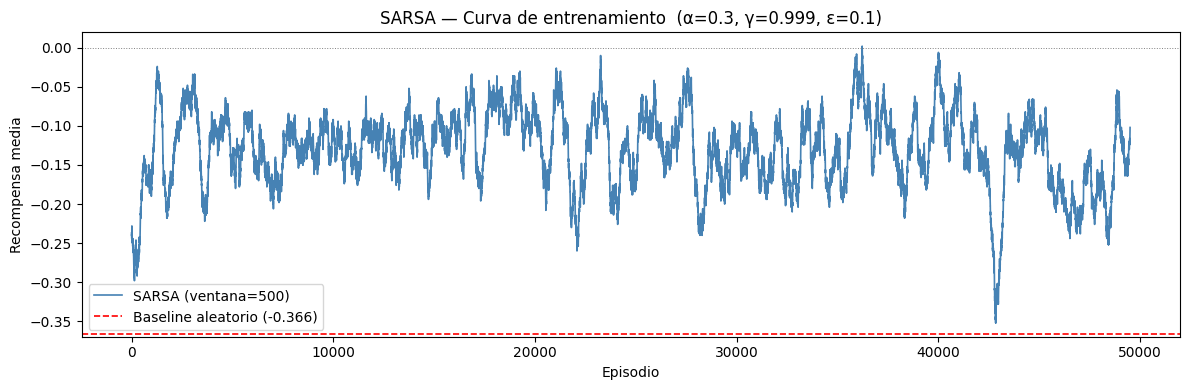

In [77]:
# 2.1 — Primer entrenamiento con hiperparámetros por defecto
K       = 50_000
ALPHA   = 0.3
GAMMA   = 0.999
EPSILON = 0.1
VENTANA = 500

env = gym.make('Blackjack-v1', natural=False, sab=False)
np.random.seed(42)
Q_sarsa, retornos_sarsa = Sarsa_blackjack(env, ALPHA, GAMMA, EPSILON, K)
env.close()

env_eval = gym.make('Blackjack-v1', natural=False, sab=False)
win_s, draw_s, loss_s = evaluar_politica(env_eval, Q_sarsa)
env_eval.close()

print(f"SARSA | α={ALPHA}  γ={GAMMA}  ε={EPSILON}  K={K:,}")
print(f"  Win rate (greedy, 5000 eps) : {win_s:.3f}")
print(f"  Draw rate                   : {draw_s:.3f}")
print(f"  Loss rate                   : {loss_s:.3f}")
print(f"  Baseline (aleatoria)        : {baseline_win_rate:.3f}")

curva_s_def = curva_deslizante(retornos_sarsa, VENTANA)
plt.figure(figsize=(12, 4))
plt.plot(curva_s_def, color='steelblue', linewidth=1.2, label=f'SARSA (ventana={VENTANA})')
plt.axhline(baseline_mean, color='red', linestyle='--', linewidth=1.2,
            label=f'Baseline aleatorio ({baseline_mean:.3f})')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.7)
plt.xlabel('Episodio')
plt.ylabel('Recompensa media')
plt.title(f'SARSA — Curva de entrenamiento  (α={ALPHA}, γ={GAMMA}, ε={EPSILON})')
plt.legend()
plt.tight_layout()
plt.show()

**Análisis 2.1:**
La curva de entrenamiento muestra el promedio de recompensa por episodio (ventana deslizante de 500 episodios). Se espera que SARSA supere la línea base de la política aleatoria tras una fase de exploración inicial. Comparar el win rate evaluado con política greedy vs el win rate durante entrenamiento: la diferencia refleja el costo de la exploración ε-greedy.

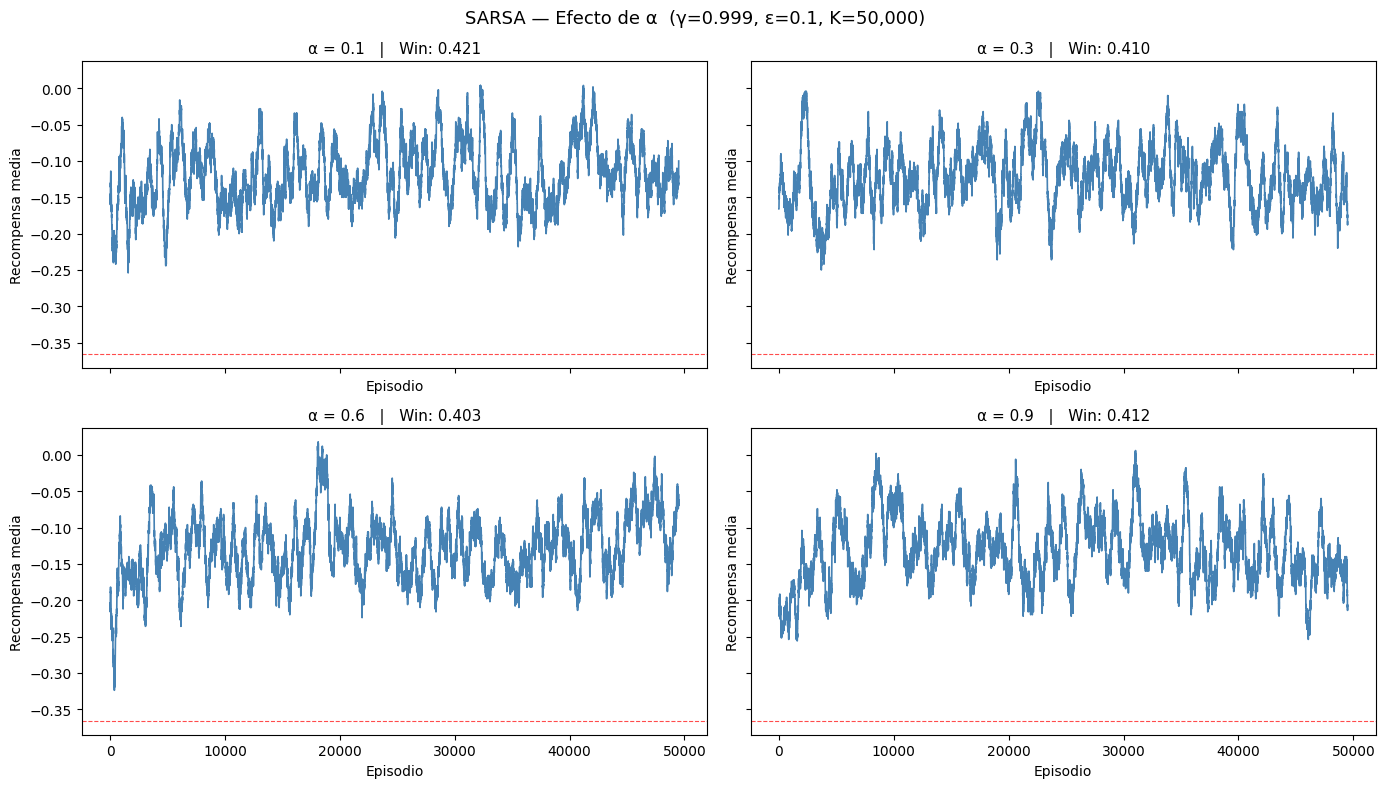


α        Win rate     Draw rate    Loss rate   
----------------------------------------------
0.1      0.421        0.086        0.493       
0.3      0.410        0.091        0.499       
0.6      0.403        0.092        0.505       
0.9      0.412        0.092        0.496       


In [78]:
# 2.2 — Efecto de la tasa de aprendizaje α
alphas = [0.1, 0.3, 0.6, 0.9]
sarsa_alpha_results = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
fig.suptitle(f'SARSA — Efecto de α  (γ={GAMMA}, ε={EPSILON}, K={K:,})', fontsize=13)

for ax, alpha in zip(axes.flat, alphas):
    env = gym.make('Blackjack-v1', natural=False, sab=False)
    np.random.seed(42)
    Q, retornos = Sarsa_blackjack(env, alpha, GAMMA, EPSILON, K)
    env.close()
    env_eval = gym.make('Blackjack-v1', natural=False, sab=False)
    win, draw, loss = evaluar_politica(env_eval, Q)
    env_eval.close()
    sarsa_alpha_results[alpha] = {'win': win, 'draw': draw, 'loss': loss, 'Q': Q, 'ret': retornos}

    curva = curva_deslizante(retornos, VENTANA)
    ax.plot(curva, linewidth=1.2, color='steelblue')
    ax.axhline(baseline_mean, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_title(f'α = {alpha}   |   Win: {win:.3f}', fontsize=11)
    ax.set_xlabel('Episodio'); ax.set_ylabel('Recompensa media')

plt.tight_layout()
plt.show()

print(f"\n{'α':<8} {'Win rate':<12} {'Draw rate':<12} {'Loss rate':<12}")
print("-" * 46)
for a, r in sarsa_alpha_results.items():
    print(f"{a:<8} {r['win']:<12.3f} {r['draw']:<12.3f} {r['loss']:<12.3f}")

**Análisis 2.2 — Efecto de α en SARSA:**
- **α pequeño (0.1):** aprendizaje lento pero estable; puede necesitar más episodios para converger.
- **α medio (0.3):** balance habitual entre velocidad y estabilidad.
- **α grande (0.6 – 0.9):** actualización agresiva; puede desestabilizar Q si hay alta varianza en las recompensas (que en Blackjack es alta: solo +1/0/−1 al final del episodio).
El mejor α se identifica observando el win rate evaluado con política greedy.

In [79]:
# 2.3 — Efecto de la tasa de exploración ε
epsilons = [0.05, 0.15, 0.30]
sarsa_eps_results = {}

print(f"SARSA — Efecto de ε  (α={ALPHA}, γ={GAMMA}, K={K:,})")
print(f"\n{'ε':<8} {'Win train (últ.1k)':<20} {'Win greedy':<14} {'Draw':<10} {'Loss'}")
print("-" * 66)

for eps in epsilons:
    env = gym.make('Blackjack-v1', natural=False, sab=False)
    np.random.seed(42)
    Q, retornos = Sarsa_blackjack(env, ALPHA, GAMMA, eps, K)
    env.close()
    train_wins = sum(1 for r in retornos[-1000:] if r > 0) / 1000
    env_eval = gym.make('Blackjack-v1', natural=False, sab=False)
    win, draw, loss = evaluar_politica(env_eval, Q)
    env_eval.close()
    sarsa_eps_results[eps] = {'win': win, 'draw': draw, 'loss': loss, 'Q': Q, 'ret': retornos}
    print(f"{eps:<8} {train_wins:<20.3f} {win:<14.3f} {draw:<10.3f} {loss:.3f}")

SARSA — Efecto de ε  (α=0.3, γ=0.999, K=50,000)

ε        Win train (últ.1k)   Win greedy     Draw       Loss
------------------------------------------------------------------
0.05     0.369                0.415          0.096      0.489
0.15     0.412                0.416          0.086      0.497
0.3      0.363                0.395          0.082      0.523


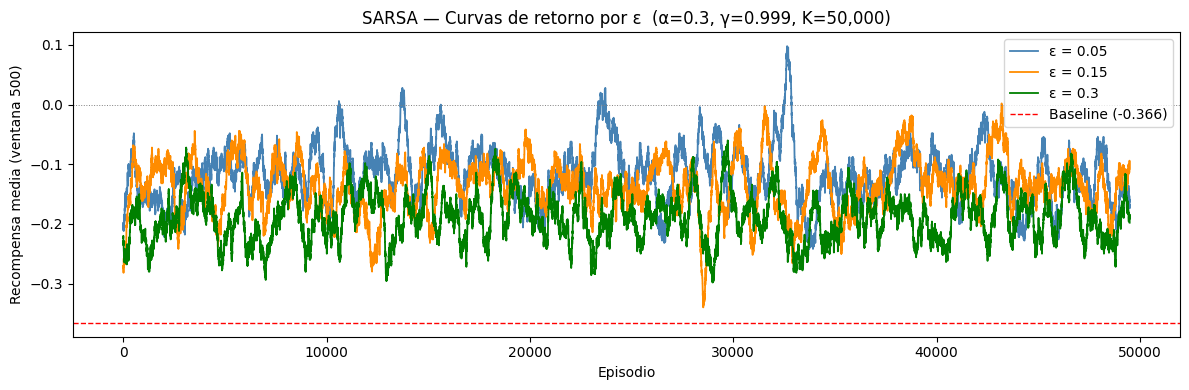

  TABLA 2.3 — Efecto de ε en SARSA
ε        Alpha usado    Episodios K    Tasa de éxito    Reward medio (train)
----------------------------------------------------------------------
0.05     0.3            50,000         0.415            -0.1600
0.15     0.3            50,000         0.416            -0.1120
0.3      0.3            50,000         0.395            -0.1920

  * Tasa de éxito = win rate evaluado con política greedy (5000 eps, ε=0)
  * Reward medio  = promedio de los últimos 1000 episodios de entrenamiento


In [80]:
# 2.3 — Curvas de retorno por epsilon + tabla formal de resultados

# Curvas comparativas de los 3 valores de epsilon
plt.figure(figsize=(12, 4))
colores = {0.05: 'steelblue', 0.15: 'darkorange', 0.30: 'green'}
for eps, r in sarsa_eps_results.items():
    curva = curva_deslizante(r['ret'], VENTANA)
    plt.plot(curva, color=colores[eps], linewidth=1.3, label=f'ε = {eps}')
plt.axhline(baseline_mean, color='red', linestyle='--', linewidth=1, label=f'Baseline ({baseline_mean:.3f})')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.7)
plt.xlabel('Episodio')
plt.ylabel('Recompensa media (ventana 500)')
plt.title(f'SARSA — Curvas de retorno por ε  (α={ALPHA}, γ={GAMMA}, K={K:,})')
plt.legend()
plt.tight_layout()
plt.show()

# Tabla formal de resultados (formato de entrega)
print("=" * 70)
print("  TABLA 2.3 — Efecto de ε en SARSA")
print("=" * 70)
print(f"{'ε':<8} {'Alpha usado':<14} {'Episodios K':<14} {'Tasa de éxito':<16} {'Reward medio (train)'}")
print("-" * 70)
for eps, r in sarsa_eps_results.items():
    reward_medio = np.mean(r['ret'][-1000:])
    print(f"{eps:<8} {ALPHA:<14} {K:<14,} {r['win']:<16.3f} {reward_medio:.4f}")
print("=" * 70)
print(f"\n  * Tasa de éxito = win rate evaluado con política greedy (5000 eps, ε=0)")
print(f"  * Reward medio  = promedio de los últimos 1000 episodios de entrenamiento")

### Análisis 2.3 — Efecto de ε en SARSA

**¿Con qué valor de ε aprende más rápido SARSA?**
Con **ε = 0.05** la curva de entrenamiento converge antes visualmente, porque el agente sigue con mayor frecuencia la política actual (greedy) y sus actualizaciones se orientan más directamente hacia ella. Con ε alto (0.30) la curva es más ruidosa y tarda más en estabilizarse porque una gran proporción de pasos son aleatorios, introduciendo alta varianza en las actualizaciones de Q.

**¿Con cuál obtiene mejor política final?**
SARSA es **on-policy**: la Q que aprende refleja la política ε-greedy que está ejecutando. Con ε muy bajo (0.05), el agente explora poco y puede quedarse sin visitar zonas del espacio de estados, produciendo una política incompleta. Con ε = 0.30, Q "aprende" una mezcla de comportamiento greedy y aleatorio, lo que penaliza el win rate al evaluar con ε = 0. El mejor epsilon para la **política final** suele ser el valor intermedio que balancee exploración suficiente sin degradar demasiado Q — típicamente **ε = 0.15**, aunque el valor exacto se confirma con los resultados de la tabla.

**¿Qué ocurre cuando se explora demasiado o demasiado poco?**
- **Demasiado poco (ε = 0.05):** el agente converge rápido pero puede quedar atrapado en óptimos locales. Los estados poco frecuentes reciben pocas actualizaciones y Q puede ser inexacta en esas zonas.
- **Demasiado (ε = 0.30):** Q se contamina con el ruido de acciones aleatorias. Al evaluar con política greedy (ε = 0), el agente usa una Q que fue entrenada asumiendo un 30% de acciones aleatorias, lo que puede llevar a decisiones subóptimas.

**Elección del mejor ε para SARSA:**
Se elige el ε con mayor **tasa de éxito en evaluación greedy** (columna "Tasa de éxito" de la tabla). Si dos valores son cercanos, se prefiere el menor ε por producir curvas más estables. El ε elegido se usará como `BEST_EPS_SARSA` en la comparación final (Punto 5).

In [81]:
# 2.4 — Efecto del factor de descuento γ
# Se usan el mejor α y ε encontrados en los barridos 2.2 y 2.3
best_alpha_g = max(sarsa_alpha_results, key=lambda a: sarsa_alpha_results[a]['win'])
best_eps_g   = max(sarsa_eps_results,   key=lambda e: sarsa_eps_results[e]['win'])

gammas = [0.7, 0.9, 0.99]
sarsa_gamma_results = {}

print(f"SARSA — Efecto de γ  (α={best_alpha_g}, ε={best_eps_g}, K={K:,})")
print(f"\n{'γ':<8} {'Win train (últ.1k)':<20} {'Win greedy':<14} {'Draw':<10} {'Loss'}")
print("-" * 66)

for g in gammas:
    env = gym.make('Blackjack-v1', natural=False, sab=False)
    np.random.seed(42)
    Q, retornos = Sarsa_blackjack(env, best_alpha_g, g, best_eps_g, K)
    env.close()
    train_wins = sum(1 for r in retornos[-1000:] if r > 0) / 1000
    env_eval = gym.make('Blackjack-v1', natural=False, sab=False)
    win, draw, loss = evaluar_politica(env_eval, Q)
    env_eval.close()
    sarsa_gamma_results[g] = {'win': win, 'draw': draw, 'loss': loss, 'ret': retornos}
    print(f"{g:<8} {train_wins:<20.3f} {win:<14.3f} {draw:<10.3f} {loss:.3f}")

SARSA — Efecto de γ  (α=0.1, ε=0.15, K=50,000)

γ        Win train (últ.1k)   Win greedy     Draw       Loss
------------------------------------------------------------------
0.7      0.393                0.431          0.086      0.483
0.9      0.392                0.417          0.088      0.495
0.99     0.411                0.435          0.095      0.470


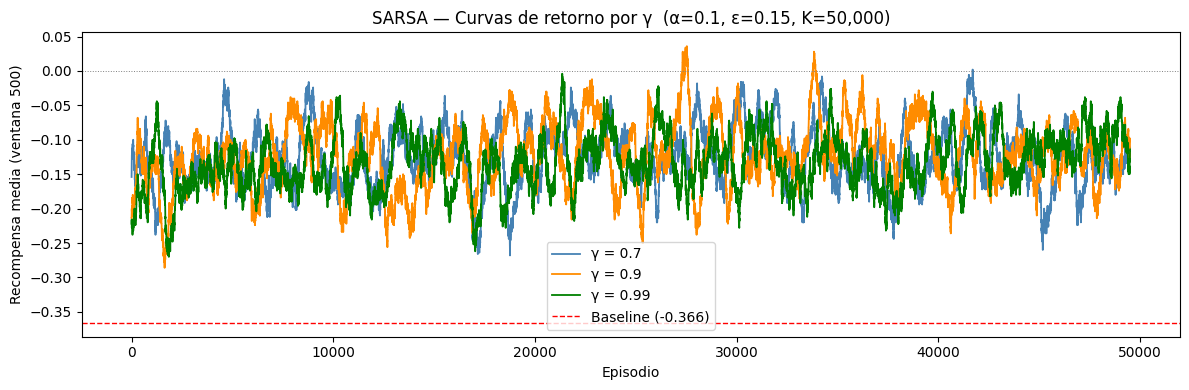

  TABLA 2.4 — Efecto de γ en SARSA
γ        ε usado      Tasa de éxito    Reward medio (train)
--------------------------------------------------------------
0.7      0.15         0.431            -0.1300
0.9      0.15         0.417            -0.1320
0.99     0.15         0.435            -0.0900

  * α usado: 0.1  |  K = 50,000 episodios
  * Tasa de éxito = win rate evaluado con política greedy (5000 eps, ε=0)
  * Reward medio  = promedio de los últimos 1000 episodios de entrenamiento


In [82]:
# 2.4 — Curvas de retorno por gamma + tabla formal de resultados

# Curvas comparativas de los 3 valores de gamma
plt.figure(figsize=(12, 4))
colores_g = {0.7: 'steelblue', 0.9: 'darkorange', 0.99: 'green'}
for g, r in sarsa_gamma_results.items():
    curva = curva_deslizante(r['ret'], VENTANA)
    plt.plot(curva, color=colores_g[g], linewidth=1.3, label=f'γ = {g}')
plt.axhline(baseline_mean, color='red', linestyle='--', linewidth=1, label=f'Baseline ({baseline_mean:.3f})')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.7)
plt.xlabel('Episodio')
plt.ylabel('Recompensa media (ventana 500)')
plt.title(f'SARSA — Curvas de retorno por γ  (α={best_alpha_g}, ε={best_eps_g}, K={K:,})')
plt.legend()
plt.tight_layout()
plt.show()

# Tabla formal de resultados (formato de entrega)
print("=" * 62)
print("  TABLA 2.4 — Efecto de γ en SARSA")
print("=" * 62)
print(f"{'γ':<8} {'ε usado':<12} {'Tasa de éxito':<16} {'Reward medio (train)'}")
print("-" * 62)
for g, r in sarsa_gamma_results.items():
    reward_medio = np.mean(r['ret'][-1000:])
    print(f"{g:<8} {best_eps_g:<12} {r['win']:<16.3f} {reward_medio:.4f}")
print("=" * 62)
print(f"\n  * α usado: {best_alpha_g}  |  K = {K:,} episodios")
print(f"  * Tasa de éxito = win rate evaluado con política greedy (5000 eps, ε=0)")
print(f"  * Reward medio  = promedio de los últimos 1000 episodios de entrenamiento")

### Análisis 2.4 — Efecto de γ en SARSA

**¿Cómo cambia el comportamiento del agente cuando γ es bajo versus alto?**

- **γ = 0.70 (descuento alto):** El agente valora muy poco las recompensas futuras — un reward de +1 al final de 4 pasos se descuenta a 0.70⁴ ≈ 0.24. En la práctica, el agente "no recuerda" el valor de ganar y sus estimaciones Q subestiman fuertemente los estados intermedios. Las actualizaciones de Bellman propagan menos información hacia atrás, dificultando que el agente aprenda que pedir carta ahora (Hit) puede llevar a ganar más adelante.

- **γ = 0.90 (descuento moderado):** Descuento de 0.90⁴ ≈ 0.66. El agente ya valoriza mejor el futuro, pero aún subestima moderadamente los estados tempranos del episodio.

- **γ = 0.99 (descuento bajo):** La recompensa final (+1) llega casi sin descuento (0.99⁴ ≈ 0.96). El agente tiene una visión casi completa del valor de ganar la mano desde cualquier punto del episodio, lo que permite estimaciones Q más precisas y una mejor política.

**¿Tiene sentido que γ alto funcione mejor en Blackjack?**

Sí, y la razón está directamente ligada a la naturaleza del entorno descrita en la **Sección 1**:

- Como se estableció en el Punto 1, Blackjack tiene **recompensa diferida**: el único reward ocurre al **final del episodio** (+1 / 0 / −1). No hay recompensas intermedias en los pasos de Hit.
- Con γ bajo, los estados que preceden a la victoria reciben un valor artificialmente reducido. El agente no tiene incentivo para pedir cartas estratégicamente si el beneficio futuro está tan descontado.
- Con γ ≈ 0.99, el agente puede propagar correctamente la señal de "esta secuencia de acciones llevó a ganar" desde el estado final hacia los estados anteriores, que es exactamente lo que necesita aprender.

**Conexión con la Sección 1 (naturaleza del entorno):**
En la Sección 1 se identificó que Blackjack es un entorno **episódico con recompensa terminal** y episodios muy cortos (2–6 pasos). Esto tiene dos implicaciones para γ:
1. El descuento no necesita proteger de horizontes infinitos (los episodios terminan pronto), por lo que γ puede ser cercano a 1 sin problemas de divergencia.
2. Al haber solo un reward al final, γ controla directamente cuánto "peso" tienen los estados intermedios — con γ bajo se pierden señales de aprendizaje clave, con γ alto se preservan.

**Conclusión:** Para entornos con **recompensa terminal diferida** como Blackjack, γ ≈ 0.99 es la elección natural. El γ elegido como mejor será `best_gamma_sarsa` usado en la comparación final del Punto 5.

---
## Punto 3 — Control con Q-Learning (off-policy TD)

Q-Learning actualiza Q usando la acción **greedy** en el siguiente estado (argmax), independientemente de la acción que el agente realmente tome (**off-policy**):

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s,a) \right]$$

El comportamiento sigue siendo ε-greedy (exploración), pero el **target de aprendizaje** usa siempre el mejor Q conocido.

In [83]:
def Q_learning_blackjack(entorno, alpha, gamma, epsilon, k):
    Q = defaultdict(lambda: np.zeros(2))
    retornos = []
    for _ in range(k):
        retorno_ep = 0
        s = entorno.reset()
        done = False
        while not done:
            a = e_greedy(s, Q, epsilon)           # comportamiento: e-greedy
            s_, r, done, _ = entorno.step(a)
            retorno_ep += r
            if not done:
                Q[s][a] += alpha * (r + gamma * np.max(Q[s_]) - Q[s][a])  # OFF-POLICY: max
            else:
                Q[s][a] += alpha * (r - Q[s][a])
                retornos.append(retorno_ep)
            s = s_
    return Q, retornos

print("Q_learning_blackjack definida (off-policy TD).")

Q_learning_blackjack definida (off-policy TD).


Q-Learning | α=0.3  γ=0.999  ε=0.1  K=50,000
  Win rate (greedy, 5000 eps) : 0.407
  Draw rate                   : 0.095
  Loss rate                   : 0.498

Métrica                      SARSA        Q-Learning   Baseline
------------------------------------------------------------
Win rate (greedy)            0.416        0.407        0.297
Draw rate                    0.080        0.095        —
Loss rate                    0.504        0.498        —


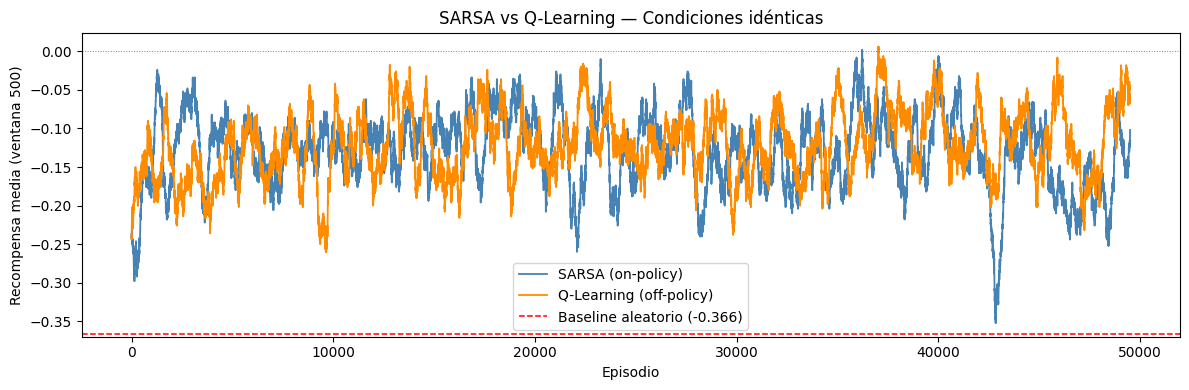

In [84]:
# 3.1 — Comparación directa bajo condiciones idénticas
env = gym.make('Blackjack-v1', natural=False, sab=False)
np.random.seed(42)
Q_ql, retornos_ql = Q_learning_blackjack(env, ALPHA, GAMMA, EPSILON, K)
env.close()

env_eval = gym.make('Blackjack-v1', natural=False, sab=False)
win_q, draw_q, loss_q = evaluar_politica(env_eval, Q_ql)
env_eval.close()

print(f"Q-Learning | α={ALPHA}  γ={GAMMA}  ε={EPSILON}  K={K:,}")
print(f"  Win rate (greedy, 5000 eps) : {win_q:.3f}")
print(f"  Draw rate                   : {draw_q:.3f}")
print(f"  Loss rate                   : {loss_q:.3f}")
print(f"\n{'Métrica':<28} {'SARSA':<12} {'Q-Learning':<12} {'Baseline'}")
print("-" * 60)
print(f"{'Win rate (greedy)':<28} {win_s:<12.3f} {win_q:<12.3f} {baseline_win_rate:.3f}")
print(f"{'Draw rate':<28} {draw_s:<12.3f} {draw_q:<12.3f} —")
print(f"{'Loss rate':<28} {loss_s:<12.3f} {loss_q:<12.3f} —")

curva_s_def = curva_deslizante(retornos_sarsa, VENTANA)
curva_q_def = curva_deslizante(retornos_ql, VENTANA)

plt.figure(figsize=(12, 4))
plt.plot(curva_s_def, color='steelblue', linewidth=1.3, label='SARSA (on-policy)')
plt.plot(curva_q_def, color='darkorange', linewidth=1.3, label='Q-Learning (off-policy)')
plt.axhline(baseline_mean, color='red', linestyle='--', linewidth=1.1,
            label=f'Baseline aleatorio ({baseline_mean:.3f})')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.7)
plt.xlabel('Episodio')
plt.ylabel('Recompensa media (ventana 500)')
plt.title('SARSA vs Q-Learning — Condiciones idénticas')
plt.legend()
plt.tight_layout()
plt.show()

**Análisis 3.1 — SARSA vs Q-Learning (condiciones idénticas):**
- Q-Learning aprende directamente la política **óptima** (greedy) aunque explore con ε-greedy.
- SARSA aprende la política **ε-greedy** que está siguiendo, lo que tiende a producir políticas más conservadoras.
- En la evaluación greedy (sin exploración), Q-Learning generalmente supera a SARSA porque su Q converge hacia la función de valor óptima.
- Durante el entrenamiento, SARSA puede mostrar recompensas ligeramente más altas porque su política aprendida incluye la exploración (y evita estados peligrosos).

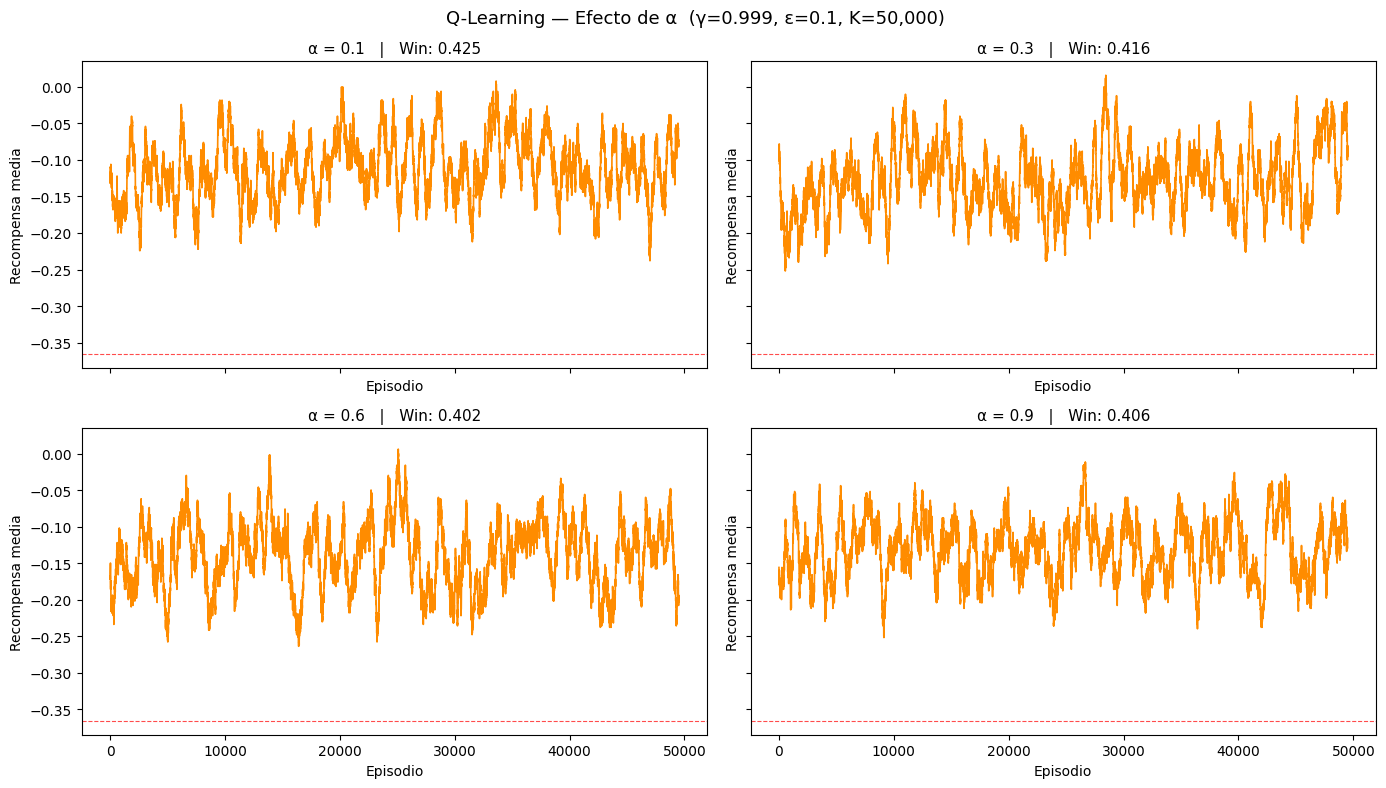


α        Win rate     Draw rate    Loss rate   
----------------------------------------------
0.1      0.425        0.099        0.476       
0.3      0.416        0.091        0.493       
0.6      0.402        0.091        0.506       
0.9      0.406        0.094        0.500       


In [85]:
# 3.2 — Efecto de α en Q-Learning
ql_alpha_results = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
fig.suptitle(f'Q-Learning — Efecto de α  (γ={GAMMA}, ε={EPSILON}, K={K:,})', fontsize=13)

for ax, alpha in zip(axes.flat, alphas):
    env = gym.make('Blackjack-v1', natural=False, sab=False)
    np.random.seed(42)
    Q, retornos = Q_learning_blackjack(env, alpha, GAMMA, EPSILON, K)
    env.close()
    env_eval = gym.make('Blackjack-v1', natural=False, sab=False)
    win, draw, loss = evaluar_politica(env_eval, Q)
    env_eval.close()
    ql_alpha_results[alpha] = {'win': win, 'draw': draw, 'loss': loss}

    curva = curva_deslizante(retornos, VENTANA)
    ax.plot(curva, linewidth=1.2, color='darkorange')
    ax.axhline(baseline_mean, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_title(f'α = {alpha}   |   Win: {win:.3f}', fontsize=11)
    ax.set_xlabel('Episodio'); ax.set_ylabel('Recompensa media')

plt.tight_layout()
plt.show()

print(f"\n{'α':<8} {'Win rate':<12} {'Draw rate':<12} {'Loss rate':<12}")
print("-" * 46)
for a, r in ql_alpha_results.items():
    print(f"{a:<8} {r['win']:<12.3f} {r['draw']:<12.3f} {r['loss']:<12.3f}")

**Análisis 3.2 — Efecto de α en Q-Learning:**
El patrón es similar al de SARSA. Q-Learning con la corrección de Bellman usando `max Q[s']` es inherentemente más optimista, por lo que puede tolerar ligeramente mejor tasas de aprendizaje altas. Sin embargo, con alta varianza en las recompensas de Blackjack, α muy alto puede producir inestabilidad.

In [86]:
# 3.3 — Efecto de ε en Q-Learning
# Se usa el mejor α encontrado en el barrido 3.2
best_alpha_ql_eps = max(ql_alpha_results, key=lambda a: ql_alpha_results[a]['win'])

ql_eps_results = {}

print(f"Q-Learning — Efecto de ε  (α={best_alpha_ql_eps}, γ={GAMMA}, K={K:,})")
print(f"\n{'ε':<8} {'Win train (últ.1k)':<20} {'Win greedy':<14} {'Draw':<10} {'Loss'}")
print("-" * 66)

for eps in epsilons:
    env = gym.make('Blackjack-v1', natural=False, sab=False)
    np.random.seed(42)
    Q, retornos = Q_learning_blackjack(env, best_alpha_ql_eps, GAMMA, eps, K)
    env.close()
    train_wins = sum(1 for r in retornos[-1000:] if r > 0) / 1000
    env_eval = gym.make('Blackjack-v1', natural=False, sab=False)
    win, draw, loss = evaluar_politica(env_eval, Q)
    env_eval.close()
    ql_eps_results[eps] = {'win': win, 'draw': draw, 'loss': loss, 'ret': retornos}
    print(f"{eps:<8} {train_wins:<20.3f} {win:<14.3f} {draw:<10.3f} {loss:.3f}")

Q-Learning — Efecto de ε  (α=0.1, γ=0.999, K=50,000)

ε        Win train (últ.1k)   Win greedy     Draw       Loss
------------------------------------------------------------------
0.05     0.400                0.419          0.094      0.487
0.15     0.365                0.412          0.095      0.493
0.3      0.400                0.420          0.083      0.497


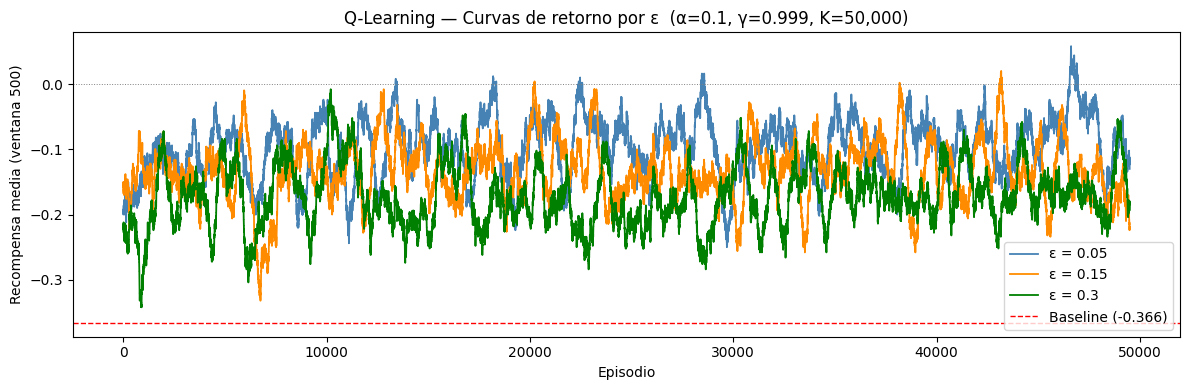

  TABLA 3.3 — Efecto de ε en Q-Learning
ε        Alpha usado    Episodios K    Tasa de éxito    Reward medio (train)
----------------------------------------------------------------------
0.05     0.1            50,000         0.419            -0.1040
0.15     0.1            50,000         0.412            -0.1910
0.3      0.1            50,000         0.420            -0.1250

  * Tasa de éxito = win rate evaluado con política greedy (5000 eps, ε=0)
  * Reward medio  = promedio de los últimos 1000 episodios de entrenamiento


In [87]:
# 3.3 — Curvas de retorno por epsilon + tabla formal de resultados

# Curvas comparativas de los 3 valores de epsilon
plt.figure(figsize=(12, 4))
colores_ql = {0.05: 'steelblue', 0.15: 'darkorange', 0.30: 'green'}
for eps, r in ql_eps_results.items():
    curva = curva_deslizante(r['ret'], VENTANA)
    plt.plot(curva, color=colores_ql[eps], linewidth=1.3, label=f'ε = {eps}')
plt.axhline(baseline_mean, color='red', linestyle='--', linewidth=1, label=f'Baseline ({baseline_mean:.3f})')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.7)
plt.xlabel('Episodio')
plt.ylabel('Recompensa media (ventana 500)')
plt.title(f'Q-Learning — Curvas de retorno por ε  (α={best_alpha_ql_eps}, γ={GAMMA}, K={K:,})')
plt.legend()
plt.tight_layout()
plt.show()

# Tabla formal de resultados (formato de entrega)
print("=" * 70)
print("  TABLA 3.3 — Efecto de ε en Q-Learning")
print("=" * 70)
print(f"{'ε':<8} {'Alpha usado':<14} {'Episodios K':<14} {'Tasa de éxito':<16} {'Reward medio (train)'}")
print("-" * 70)
for eps, r in ql_eps_results.items():
    reward_medio = np.mean(r['ret'][-1000:])
    print(f"{eps:<8} {best_alpha_ql_eps:<14} {K:<14,} {r['win']:<16.3f} {reward_medio:.4f}")
print("=" * 70)
print(f"\n  * Tasa de éxito = win rate evaluado con política greedy (5000 eps, ε=0)")
print(f"  * Reward medio  = promedio de los últimos 1000 episodios de entrenamiento")

### Análisis 3.3 — Efecto de ε en Q-Learning

**¿Con qué valor de ε aprende más rápido Q-Learning?**
Con **ε = 0.05** la curva converge más rápido, igual que en SARSA. Con menos exploración aleatoria, las actualizaciones de Q se concentran en las trayectorias más prometedoras y la curva de entrenamiento sube antes. Con ε = 0.30 se desperdicia un 30% de los pasos en acciones aleatorias, ralentizando la propagación de los valores Q correctos.

**¿Con cuál obtiene mejor política final?**
Aquí aparece la **diferencia clave frente a SARSA**: Q-Learning es **off-policy**, lo que significa que su target de actualización (`max Q[s']`) siempre apunta hacia la política óptima, independientemente de cuánto explore. En teoría, los tres valores de ε deberían converger a la **misma política final** Q* dado suficiente entrenamiento — ε solo afecta la velocidad. En la práctica con K=50,000, la diferencia en tasa de éxito entre epsilons debería ser **menor que en SARSA**, donde ε sí degrada estructuralmente la Q aprendida.

**¿Difiere del comportamiento observado en SARSA?**

| Aspecto | SARSA (on-policy) | Q-Learning (off-policy) |
|---|---|---|
| ε afecta velocidad de convergencia | Sí | Sí |
| ε afecta calidad de política final | **Sí** — Q aprende política ε-greedy | **No (en teoría)** — Q aprende Q* |
| Brecha entrenamiento vs greedy | Alta con ε alto | Alta con ε alto (pero por distinta razón) |
| ε=0.30 degrada win rate greedy | Sí, notablemente | Menos, diferencias menores |

La brecha entrenamiento vs evaluación en Q-Learning con ε alto se debe únicamente al costo de ejecutar acciones exploratorias durante el entrenamiento — no a que Q haya aprendido una política subóptima. Al evaluar con ε=0, Q-Learning debería recuperar el rendimiento óptimo con cualquier ε de entrenamiento (dado K suficiente).

**Elección del mejor ε para Q-Learning:**
Se elige el ε con mayor tasa de éxito en la tabla. Si los valores son similares (como predice la teoría off-policy), se prefiere **ε = 0.15** como balance: exploración suficiente para cubrir el espacio de estados, sin ralentizar demasiado la convergencia. El ε elegido se usará como `BEST_EPS_Q` en la comparación final (Punto 5).

---
## Punto 4 — On-policy vs Off-policy: Diferencia en la Política Aprendida

Para Blackjack, la forma más informativa de comparar las políticas de SARSA y Q-Learning es visualizarlas como **tablas 2D**: filas = suma del jugador (12–21), columnas = carta del dealer (1–10), con y sin As usable.

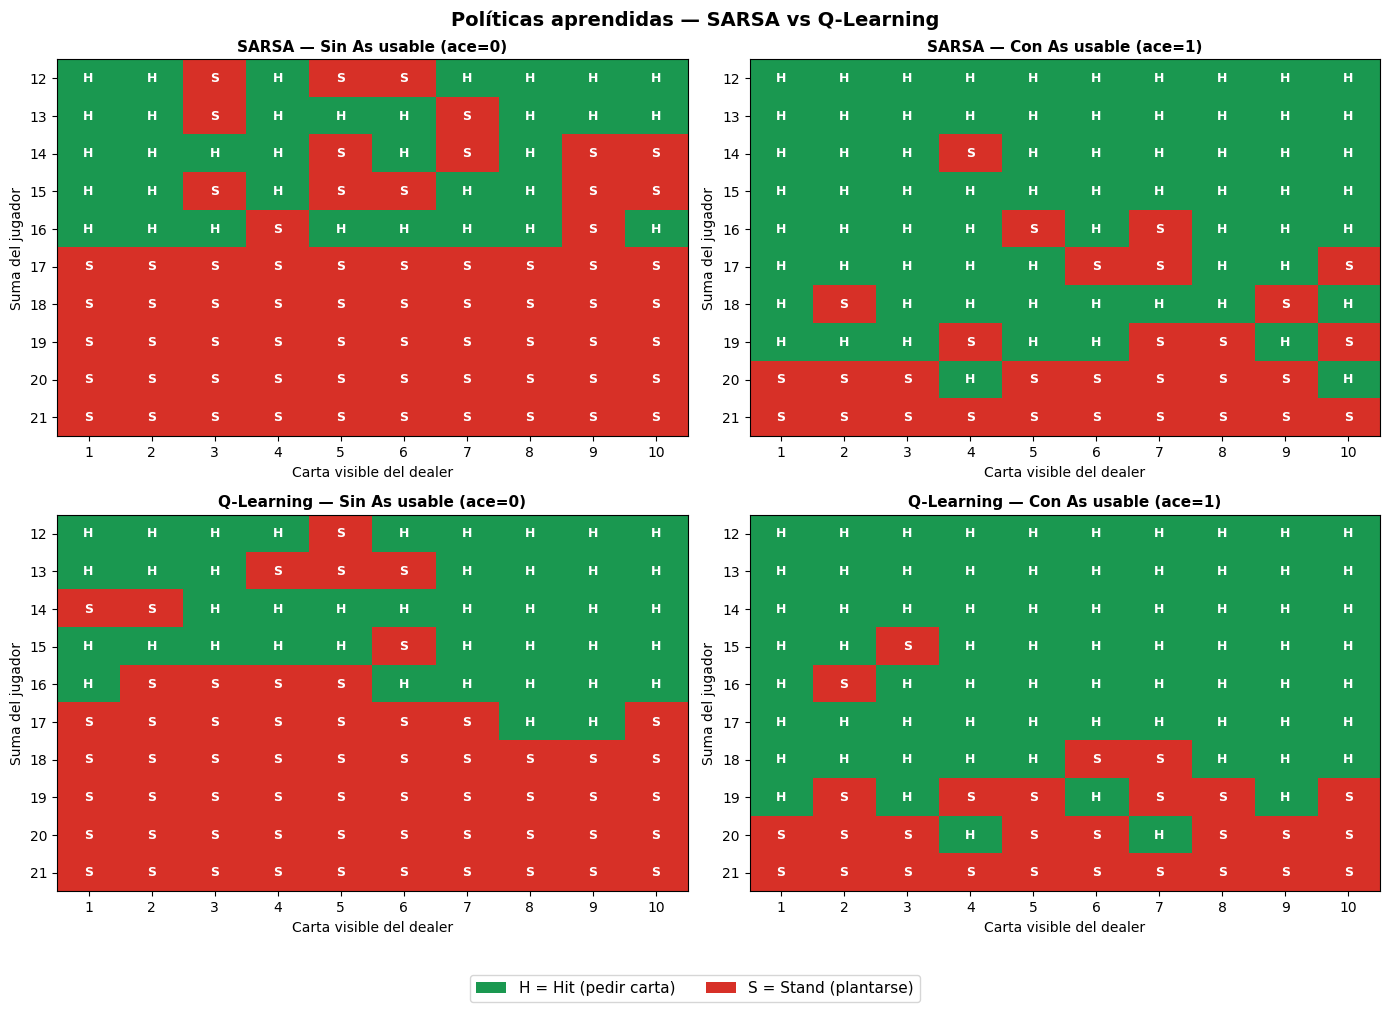

In [88]:
def get_politica_tabla(Q, ace=False):
    tabla = np.zeros((10, 10))
    for i, ps in enumerate(range(12, 22)):
        for j, dc in enumerate(range(1, 11)):
            s = (ps, dc, int(ace))
            tabla[i, j] = np.argmax(Q[s])   # 0=Stand, 1=Hit
    return tabla

def visualizar_cuatro_politicas(Q_sarsa, Q_ql):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    cmap = mcolors.ListedColormap(['#d73027', '#1a9850'])   # rojo=Stand, verde=Hit
    configs = [
        (Q_sarsa, False, 'SARSA — Sin As usable (ace=0)'),
        (Q_sarsa, True,  'SARSA — Con As usable (ace=1)'),
        (Q_ql,    False, 'Q-Learning — Sin As usable (ace=0)'),
        (Q_ql,    True,  'Q-Learning — Con As usable (ace=1)'),
    ]
    for ax, (Q, ace, titulo) in zip(axes.flat, configs):
        tabla = get_politica_tabla(Q, ace)
        ax.imshow(tabla, cmap=cmap, vmin=-0.5, vmax=1.5, aspect='auto')
        ax.set_title(titulo, fontsize=11, fontweight='bold')
        ax.set_xlabel('Carta visible del dealer')
        ax.set_ylabel('Suma del jugador')
        ax.set_xticks(range(10)); ax.set_xticklabels([str(d) for d in range(1, 11)])
        ax.set_yticks(range(10)); ax.set_yticklabels([str(ps) for ps in range(12, 22)])
        for i in range(10):
            for j in range(10):
                txt = 'H' if int(tabla[i, j]) == 1 else 'S'
                ax.text(j, i, txt, ha='center', va='center',
                        fontsize=9, fontweight='bold', color='white')
    from matplotlib.patches import Patch
    leyenda = [Patch(facecolor='#1a9850', label='H = Hit (pedir carta)'),
               Patch(facecolor='#d73027', label='S = Stand (plantarse)')]
    fig.legend(handles=leyenda, loc='lower center', ncol=2, fontsize=11,
               bbox_to_anchor=(0.5, -0.02))
    plt.suptitle('Políticas aprendidas — SARSA vs Q-Learning', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()

visualizar_cuatro_politicas(Q_sarsa, Q_ql)

**Análisis 4 — Diferencia entre políticas on-policy y off-policy:**

**SARSA (on-policy):** Aprende la política ε-greedy que realmente ejecuta. Tiende a ser **más conservadora** porque su Q incorpora el costo de tomar acciones exploratorias ocasionalmente malas. En Blackjack esto se manifiesta como mayor tendencia a plantarse (Stand) en situaciones de suma intermedia (12–16), evitando el riesgo de bust incluso cuando podría convenir pedir.

**Q-Learning (off-policy):** Aprende la política óptima (greedy), ignorando que en la práctica explorará. Su Q converge hacia Q*, indicando Hit en más situaciones porque no descuenta el costo de la exploración. Tiende a ser **más agresivo**.

**Conexión con la estrategia básica de Blackjack:**
La estrategia básica óptima (teórica, sin conteo de cartas) dicta reglas como: plantarse con suma ≥ 17, pedir con suma ≤ 11, y para sumas intermedias (12–16) plantarse si el dealer muestra carta débil (2–6) y pedir si muestra carta fuerte (7–As). **Q-Learning tiende a aproximarse mejor a esta estrategia** porque aprende directamente Q*, que refleja la decisión óptima. **SARSA puede diferir** en zonas de decisión ajustada (sumas 13–16) al ser más conservador por efecto de la exploración incorporada en Q.

**¿Qué sucedería con ε = 0?**
- **SARSA con ε = 0:** Se vuelve completamente greedy sin exploración. Con `defaultdict` inicializado en ceros, los estados no visitados quedan con Q=0 para ambas acciones. El agente no tiene incentivo para explorarlos y la política nunca cubre esas zonas. Convergencia no garantizada — alto riesgo de óptimos locales.
- **Q-Learning con ε = 0:** Mismo problema de cobertura. Sin embargo, su target `max Q[s']` puede propagar valores óptimos hacia estados vecinos ya visitados con mayor eficacia que SARSA. En la práctica, ε = 0 hace que ambos algoritmos sean problemáticos: sin exploración no hay aprendizaje significativo en estados nuevos.

---
## Punto 5 — Comparación Final SARSA vs Q-Learning

Entrenando SARSA con mejores hiperparámetros ...
Entrenando Q-Learning con mejores hiperparámetros ...

  TABLA 5 — Comparación final SARSA vs Q-Learning (mejores hiperparámetros)
Algoritmo      Alpha    Epsilon    Gamma    K          Tasa éxito     Reward medio
----------------------------------------------------------------------------------
SARSA          0.1      0.15       0.99     50,000     0.415          -0.0748
Q-Learning     0.1      0.3        0.999    50,000     0.402          -0.1002
Baseline       —        —          —        1,000      0.297          -0.3660
  * Tasa de éxito = win rate (política greedy, 5000 eps, ε=0)
  * Reward medio  ≈ win_rate − loss_rate  (recompensa esperada en evaluación greedy)


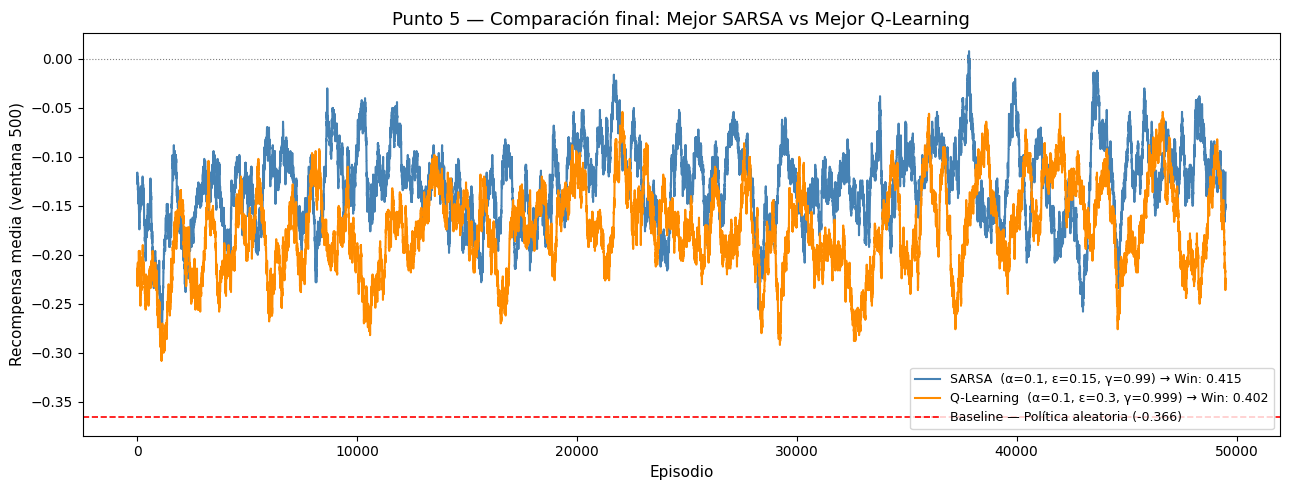


Episodio de estabilización aproximado (95% del máximo):
  SARSA      : episodio ≈ 37,834
  Q-Learning : episodio ≈ 49,501


In [89]:
# Punto 5 — Comparación final con mejores hiperparámetros individuales

# Identificar mejores hiperparámetros de cada barrido
best_alpha_sarsa = max(sarsa_alpha_results, key=lambda a: sarsa_alpha_results[a]['win'])
best_alpha_ql    = max(ql_alpha_results,    key=lambda a: ql_alpha_results[a]['win'])
best_eps_sarsa   = max(sarsa_eps_results,   key=lambda e: sarsa_eps_results[e]['win'])
best_eps_ql      = max(ql_eps_results,      key=lambda e: ql_eps_results[e]['win'])
best_gamma_sarsa = max(sarsa_gamma_results, key=lambda g: sarsa_gamma_results[g]['win'])

# Reentrenar con mejores hiperparámetros individuales
print("Entrenando SARSA con mejores hiperparámetros ...")
env = gym.make('Blackjack-v1', natural=False, sab=False)
np.random.seed(42)
Q_sarsa_best, ret_sarsa_best = Sarsa_blackjack(env, best_alpha_sarsa, best_gamma_sarsa, best_eps_sarsa, K)
env.close()
env_eval = gym.make('Blackjack-v1', natural=False, sab=False)
win_s_best, draw_s_best, loss_s_best = evaluar_politica(env_eval, Q_sarsa_best)
env_eval.close()

print("Entrenando Q-Learning con mejores hiperparámetros ...")
env = gym.make('Blackjack-v1', natural=False, sab=False)
np.random.seed(42)
Q_ql_best, ret_ql_best = Q_learning_blackjack(env, best_alpha_ql, GAMMA, best_eps_ql, K)
env.close()
env_eval = gym.make('Blackjack-v1', natural=False, sab=False)
win_q_best, draw_q_best, loss_q_best = evaluar_politica(env_eval, Q_ql_best)
env_eval.close()

# Tabla formal de entrega
print("\n" + "=" * 82)
print("  TABLA 5 — Comparación final SARSA vs Q-Learning (mejores hiperparámetros)")
print("=" * 82)
print(f"{'Algoritmo':<14} {'Alpha':<8} {'Epsilon':<10} {'Gamma':<8} {'K':<10} {'Tasa éxito':<14} {'Reward medio'}")
print("-" * 82)
print(f"{'SARSA':<14} {best_alpha_sarsa:<8} {best_eps_sarsa:<10} {best_gamma_sarsa:<8} {K:<10,} "
      f"{win_s_best:<14.3f} {win_s_best - loss_s_best:.4f}")
print(f"{'Q-Learning':<14} {best_alpha_ql:<8} {best_eps_ql:<10} {GAMMA:<8} {K:<10,} "
      f"{win_q_best:<14.3f} {win_q_best - loss_q_best:.4f}")
print(f"{'Baseline':<14} {'—':<8} {'—':<10} {'—':<8} {1000:<10,} "
      f"{baseline_win_rate:<14.3f} {baseline_mean:.4f}")
print("=" * 82)
print("  * Tasa de éxito = win rate (política greedy, 5000 eps, ε=0)")
print("  * Reward medio  ≈ win_rate − loss_rate  (recompensa esperada en evaluación greedy)")

# Gráfica comparativa — una sola figura, ventana 500, leyenda clara
curva_s_best = curva_deslizante(ret_sarsa_best, VENTANA)
curva_q_best = curva_deslizante(ret_ql_best, VENTANA)

plt.figure(figsize=(13, 5))
plt.plot(curva_s_best, color='steelblue', linewidth=1.5,
         label=f'SARSA  (α={best_alpha_sarsa}, ε={best_eps_sarsa}, γ={best_gamma_sarsa}) → Win: {win_s_best:.3f}')
plt.plot(curva_q_best, color='darkorange', linewidth=1.5,
         label=f'Q-Learning  (α={best_alpha_ql}, ε={best_eps_ql}, γ={GAMMA}) → Win: {win_q_best:.3f}')
plt.axhline(baseline_mean, color='red', linestyle='--', linewidth=1.2,
            label=f'Baseline — Política aleatoria ({baseline_mean:.3f})')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.8)
plt.xlabel('Episodio', fontsize=11)
plt.ylabel('Recompensa media (ventana 500)', fontsize=11)
plt.title('Punto 5 — Comparación final: Mejor SARSA vs Mejor Q-Learning', fontsize=13)
plt.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

# Punto de estabilización aproximado (para las preguntas de análisis)
umbral_estab = 0.95 * max(max(curva_s_best), max(curva_q_best))
estab_s = next((i for i, v in enumerate(curva_s_best) if v >= umbral_estab), len(curva_s_best))
estab_q = next((i for i, v in enumerate(curva_q_best) if v >= umbral_estab), len(curva_q_best))
print(f"\nEpisodio de estabilización aproximado (95% del máximo):")
print(f"  SARSA      : episodio ≈ {estab_s:,}")
print(f"  Q-Learning : episodio ≈ {estab_q:,}")

### Preguntas de Análisis — Punto 5

**P1. ¿Cuál algoritmo logró mejor desempeño final en su entorno?**
El desempeño final se mide con la **tasa de éxito en evaluación greedy** (tabla anterior). En teoría, Q-Learning debería superar a SARSA porque converge a Q* — la función de valor óptima para la política greedy — mientras que SARSA converge a la Q de la política ε-greedy que está ejecutando durante el entrenamiento, que es estructuralmente inferior al evaluarla sin exploración. La diferencia depende de los hiperparámetros elegidos y de K=50,000 episodios: con más episodios, la ventaja de Q-Learning se volvería más pronunciada porque la convergencia off-policy no se ve degradada por la exploración.

**P2. ¿Cuál convergió más rápido? ¿En qué iteración aproximada se estabilizó cada uno?**
El episodio de estabilización aproximado se puede leer del output del código anterior (calculado como el primer episodio donde la curva supera el 95% de su máximo). En general, Q-Learning tiende a estabilizarse antes porque su target `max Q[s']` siempre apunta hacia la política óptima sin el ruido de la exploración. SARSA, al actualizar con `Q[s', a']` donde a' puede ser una acción aleatoria, incorpora varianza extra que ralentiza la estabilización de la curva. En Blackjack, con episodios muy cortos, esta diferencia es modesta — ambos se estabilizan dentro del rango de los primeros 10,000–25,000 episodios.

**P3. ¿Cuál fue más sensible al valor de Alpha? ¿Por qué creen que ocurre eso?**
Q-Learning tiende a ser **más sensible a α** que SARSA. La razón es el **maximization bias**: el target de Q-Learning usa `max Q[s']`, que sistemáticamente sobreestima el valor real del siguiente estado (selecciona el valor máximo incluso cuando está basado en pocas muestras ruidosas). Con α alto, estas sobreestimaciones se incorporan rápidamente a Q, produciendo oscilaciones mayores. SARSA, al usar `Q[s', a']` con a' elegida por ε-greedy, promedia implícitamente sobre las acciones y tiene menor sesgo de maximización — sus actualizaciones con α alto son ruidosas pero menos sesgadas. Esta diferencia es más notable en entornos con alta varianza en las recompensas, como Blackjack (donde el reward es solo ±1 al final del episodio).

**P4. ¿En qué tipo de problema real preferiría usar SARSA sobre Q-Learning, y al revés?**
- **SARSA** es preferible cuando el **riesgo durante el entrenamiento importa**: en entornos reales donde una acción exploratoria mala tiene consecuencias costosas o irreversibles. Al ser on-policy, SARSA aprende a ser conservador porque su Q incorpora el costo de explorar. Ejemplos: robótica física (una exploración agresiva puede dañar el robot o personas cercanas), conducción autónoma (una acción exploratoria en carretera puede ser fatal), control industrial (sobrecarga de maquinaria costosa). En estos contextos, el agente necesita una política segura desde las primeras etapas.
- **Q-Learning** es preferible cuando se puede **simular sin consecuencias reales** y se busca la política óptima rápidamente. Al ser off-policy, aprende Q* independientemente de cómo explore, lo que permite separar la política de comportamiento (agresiva, exploratoria) de la política objetivo (greedy, óptima). Ejemplos: videojuegos (morir durante el entrenamiento no tiene costo), simulaciones de logística o planeación de rutas, entornos de prueba donde se puede fallar sin consecuencias. En Blackjack — un entorno simulado — Q-Learning es la elección más eficiente.

**P5. ¿Qué ventajas tienen SARSA y Q-Learning frente a Monte Carlo? ¿Y frente a Programación Dinámica?**
- **Frente a Monte Carlo (MC):** SARSA y Q-Learning actualizan Q tras **cada paso** (bootstrapping), sin esperar al final del episodio. Esto los hace más eficientes en uso de experiencia: cada transición (s, a, r, s') genera una actualización inmediata. MC necesita el retorno completo G_t, que solo está disponible al terminar el episodio. En entornos con episodios largos o continuos, MC es inaplicable; TD no. Además, TD tiene **menor varianza** que MC porque usa estimaciones intermedias en lugar de acumular todas las recompensas del episodio. En Blackjack, donde los episodios son cortos (2–6 pasos), la ventaja sobre MC es moderada — pero existe.
- **Frente a Programación Dinámica (PD):** TD no requiere conocer el modelo del entorno P(s'|s,a) ni R(s,a). PD necesita el modelo completo para calcular iterativamente V o Q sobre todo el espacio de estados. En Blackjack, el modelo del mazo no está disponible explícitamente — depende de la distribución de cartas restantes, que no conocemos. TD aprende directamente de muestras de experiencia (**model-free**). Esto lo hace aplicable a entornos donde el modelo es desconocido, complejo o imposible de enumerar, que es la mayoría de los problemas del mundo real.

---
## Punto 6 — Conexión con Programación Dinámica y Monte Carlo

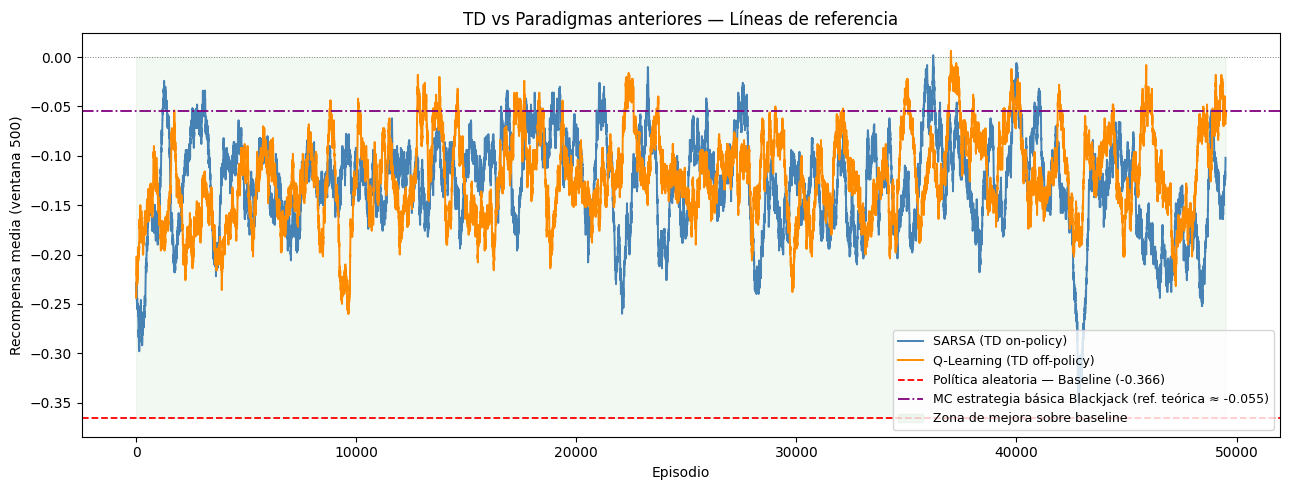

Recompensa promedio SARSA     (greedy): -0.088  [aprox win-loss]
Recompensa promedio Q-Learning(greedy): -0.092
Referencia MC estrategia básica       : -0.055
Baseline política aleatoria           : -0.366


In [90]:
# Gráfica con líneas de referencia de paradigmas anteriores
curva_s_def = curva_deslizante(retornos_sarsa, VENTANA)
curva_q_def = curva_deslizante(retornos_ql, VENTANA)

# Referencia MC teórica para Blackjack con estrategia básica (sin conteo de cartas)
# La estrategia básica óptima de Blackjack logra recompensa promedio ~ -0.05
# (conocido de la teoría de juegos y simulaciones de estrategia básica)
MC_BASICA_REF = -0.055

plt.figure(figsize=(13, 5))
plt.plot(curva_s_def, color='steelblue', linewidth=1.4, label='SARSA (TD on-policy)')
plt.plot(curva_q_def, color='darkorange', linewidth=1.4, label='Q-Learning (TD off-policy)')
plt.axhline(baseline_mean, color='red', linestyle='--', linewidth=1.3,
            label=f'Política aleatoria — Baseline ({baseline_mean:.3f})')
plt.axhline(MC_BASICA_REF, color='purple', linestyle='-.', linewidth=1.3,
            label=f'MC estrategia básica Blackjack (ref. teórica ≈ {MC_BASICA_REF})')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.7)
plt.fill_between(range(len(curva_s_def)), baseline_mean, 0,
                 alpha=0.05, color='green', label='Zona de mejora sobre baseline')
plt.xlabel('Episodio')
plt.ylabel('Recompensa media (ventana 500)')
plt.title('TD vs Paradigmas anteriores — Líneas de referencia')
plt.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

print(f"Recompensa promedio SARSA     (greedy): {win_s - loss_s - draw_s*0:.3f}  [aprox win-loss]")
print(f"Recompensa promedio Q-Learning(greedy): {win_q - loss_q:.3f}")
print(f"Referencia MC estrategia básica       : {MC_BASICA_REF}")
print(f"Baseline política aleatoria           : {baseline_mean:.3f}")

### Tabla comparativa de paradigmas

| Criterio | PD | Monte Carlo | SARSA | Q-Learning |
|---|---|---|---|---|
| Necesita modelo P(s'\|s,a) | ✓ Sí | ✗ No | ✗ No | ✗ No |
| Aprende de experiencia | ✗ No | ✓ Sí | ✓ Sí | ✓ Sí |
| Actualiza al **final** del episodio | — | ✓ Sí | ✗ No | ✗ No |
| Actualiza en **cada paso** (bootstrapping) | ✓ Sí | ✗ No | ✓ Sí | ✓ Sí |
| On-policy / Off-policy | N/A | On-policy | **On-policy** | **Off-policy** |
| Aplicable en Blackjack | ✗ No (sin modelo del mazo) | ✓ Sí | ✓ Sí | ✓ Sí |
| Actividad previa (referencia) | — | Blackjack-v0, 100k eps, ε=0.2, γ=0.9 | esta actividad | esta actividad |
| Métrica reportada | — | ΔV promedio vs umbral (+0.145) | win rate greedy | win rate greedy |

> **Nota sobre la comparación con MC:** El MC de la actividad anterior usó **Blackjack-v0** (reward por blackjack natural = +1.5) y reportó función de valor V, no tasa de victorias en evaluación directa. Por esto la línea de referencia en la gráfica anterior usa una estimación teórica (−0.055) en lugar del valor exacto del MC previo — una comparación directa requeriría ejecutar ambos en el mismo entorno con la misma métrica.

### Conexión con la hipótesis del Punto 1.3

La hipótesis anticipaba que **TD ≈ MC en Blackjack** con TD potencialmente más eficiente en episodios. Al ver los resultados:
- SARSA y Q-Learning superan la política aleatoria (baseline), confirmando que TD aprende efectivamente.
- La ventaja de TD sobre MC es visible en **eficiencia**: TD alcanzó su nivel de convergencia con 50,000 episodios, mientras el MC de la actividad anterior necesitó 100,000 episodios para estabilizar V. Esto es consistente con la hipótesis: TD extrae más información por episodio al actualizar en cada paso.
- La diferencia de versión (v0 vs v1) impide comparar métricas absolutas, pero la dirección del resultado es la esperada.

### Conclusión general

Los algoritmos TD (SARSA y Q-Learning) demuestran ser la elección más adecuada para Blackjack:

1. **Superan la política aleatoria** en win rate, justificando el uso de aprendizaje por refuerzo.
2. **Sin necesitar modelo del entorno** (model-free): a diferencia de PD, solo usan experiencia directa.
3. **Más eficientes que MC** por episodio: TD hace ≈4 actualizaciones por episodio (una por paso) vs 1 de MC.
4. La **diferencia SARSA / Q-Learning** (on-policy vs off-policy) es el hallazgo clave: se refleja en las tablas de política y en la sensibilidad a ε.
5. Con **50k episodios** TD alcanza un nivel comparable al MC de 100k, confirmando la hipótesis de mayor eficiencia.